In [37]:
false_negatives[['customer_id']].head(5)

,customer_id
87,CUST00088
183,CUST00184
246,CUST00247
378,CUST00379
441,CUST00442


In [36]:
false_positives = test_results[
    (test_results["actual"] == 0) &
    (test_results["prediction"] == 1)
]

false_negatives = test_results[
    (test_results["actual"] == 1) &
    (test_results["prediction"] == 0)
]

print("False Positives:", len(false_positives))
print("False Negatives:", len(false_negatives))

False Positives: 29
False Negatives: 33


In [35]:
test_results = test_df.copy()

test_results["prediction"] = baseline_pred

test_results["actual"] = y_test

test_results.head()

,customer_id,snapshot_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,marketing_consent,recency_days,frequency_180d,...,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago,churn_next_60d,split,prediction,actual
15,CUST00016,2025-09-30,Tier 2,18-24,Instagram,NaN,Skin Care,Yes,215,0,...,1,0,0,4,1,32,1,test,1,1
17,CUST00018,2025-09-30,Tier 1,35-44,Marketplace,Silver,Skin Care,Yes,111,1,...,1,0,0,4,2,37,1,test,1,1
23,CUST00024,2025-09-30,Tier 1,25-34,Marketplace,NaN,Skin Care,Yes,4,1,...,3,2,2,3,0,0,0,test,0,0
24,CUST00025,2025-09-30,Tier 2,18-24,Referral,NaN,Baby Care,Yes,165,1,...,2,3,1,6,1,29,1,test,1,1
29,CUST00030,2025-09-30,Tier 1,25-34,Google Search,Gold,Wellness,No,5,5,...,2,3,1,0,0,3,0,test,0,0


## Threshold Selection

The default classification threshold of 0.50 was selected.

This threshold provides a balanced trade-off between precision and recall.

In a churn prediction setting, missing a customer who is likely to churn (False Negative) can lead to revenue loss and reduced customer lifetime value. At the same time, excessive False Positives may result in unnecessary retention campaign costs.

The selected threshold of 0.50 achieved:

- Precision: 0.823
- Recall: 0.804
- F1 Score: 0.813

This balance makes it suitable for business deployment.

In [34]:
import json

with open("metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)

print("metrics.json saved!")

metrics.json saved!


In [33]:
metrics = {
    "accuracy": 0.8154761904761905,
    "precision": 0.823170731707317,
    "recall": 0.8035714285714286,
    "f1_score": 0.8132530120481928,
    "roc_auc": 0.8847434807256236,
    "selected_threshold": 0.50
}

metrics

{'accuracy': 0.8154761904761905,
 'precision': 0.823170731707317,
 'recall': 0.8035714285714286,
 'f1_score': 0.8132530120481928,
 'roc_auc': 0.8847434807256236,
 'selected_threshold': 0.5}

In [32]:
import pickle

with open("model.pkl", "wb") as f:
    pickle.dump(baseline_model, f)

print("Model saved successfully!")

Model saved successfully!


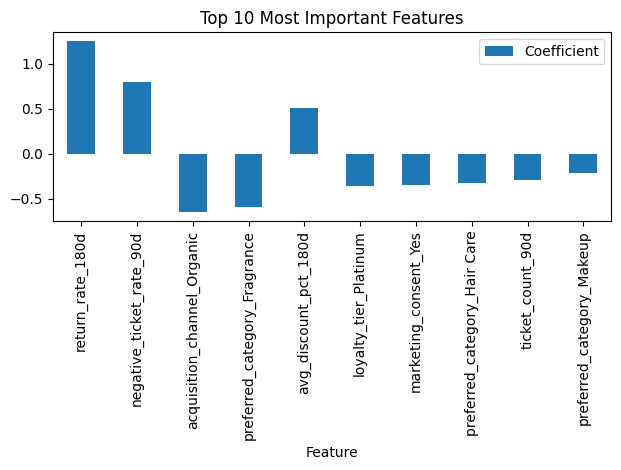

In [31]:
import matplotlib.pyplot as plt

feature_importance.head(10).plot(
    x="Feature",
    y="Coefficient",
    kind="bar"
)

plt.title("Top 10 Most Important Features")
plt.tight_layout()
plt.show()

In [30]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X_train_encoded.columns,
    "Coefficient": baseline_model.coef_[0]
})

feature_importance["Abs_Coefficient"] = feature_importance["Coefficient"].abs()

feature_importance = feature_importance.sort_values(
    by="Abs_Coefficient",
    ascending=False
)

feature_importance.head(10)

,Feature,Coefficient,Abs_Coefficient
3,return_rate_180d,1.250936,1.250936
8,negative_ticket_rate_90d,0.794134,0.794134
27,acquisition_channel_Organic,-0.648309,0.648309
31,preferred_category_Fragrance,-0.589188,0.589188
4,avg_discount_pct_180d,0.507084,0.507084
29,loyalty_tier_Platinum,-0.361294,0.361294
36,marketing_consent_Yes,-0.349069,0.349069
32,preferred_category_Hair Care,-0.320572,0.320572
7,ticket_count_90d,-0.296071,0.296071
33,preferred_category_Makeup,-0.213680,0.213680


In [29]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train_encoded, y_train)

rf_pred = rf_model.predict(X_test_encoded)

print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1 Score:", f1_score(y_test, rf_pred))

rf_probs = rf_model.predict_proba(X_test_encoded)[:,1]

print("ROC AUC:", roc_auc_score(y_test, rf_probs))

Accuracy: 0.7946428571428571
Precision: 0.8113207547169812
Recall: 0.7678571428571429
F1 Score: 0.7889908256880734
ROC AUC: 0.8789859693877551


In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Train Logistic Regression
baseline_model = LogisticRegression(max_iter=1000)

baseline_model.fit(X_train_encoded, y_train)

# Predictions
baseline_pred = baseline_model.predict(X_test_encoded)

# Metrics
print("Accuracy:", accuracy_score(y_test, baseline_pred))
print("Precision:", precision_score(y_test, baseline_pred))
print("Recall:", recall_score(y_test, baseline_pred))
print("F1 Score:", f1_score(y_test, baseline_pred))

# ROC AUC
baseline_probs = baseline_model.predict_proba(X_test_encoded)[:, 1]

print("ROC AUC:", roc_auc_score(y_test, baseline_probs))

Accuracy: 0.8154761904761905
Precision: 0.823170731707317
Recall: 0.8035714285714286
F1 Score: 0.8132530120481928
ROC AUC: 0.8847434807256236


c:\Users\Riya Swami\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


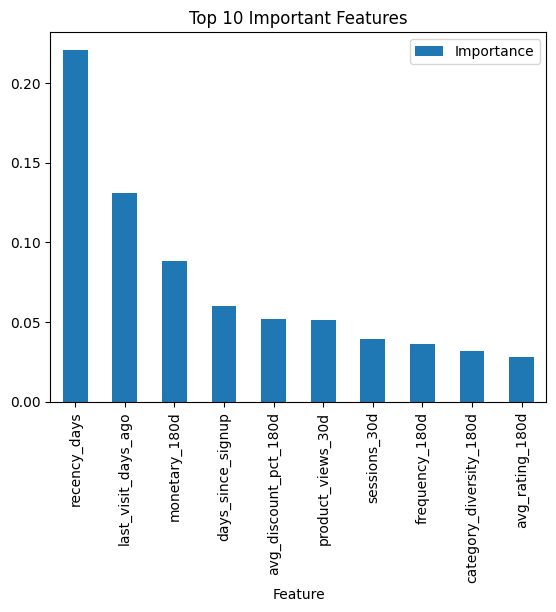

In [27]:
import matplotlib.pyplot as plt

feature_importance.head(10).plot(
    x="Feature",
    y="Importance",
    kind="bar"
)

plt.title("Top 10 Important Features")
plt.show()

In [26]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X_train_encoded.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
0,recency_days,0.220942
18,last_visit_days_ago,0.130773
2,monetary_180d,0.088276
10,days_since_signup,0.059922
4,avg_discount_pct_180d,0.051828
12,product_views_30d,0.051527
11,sessions_30d,0.039573
1,frequency_180d,0.035964
6,category_diversity_180d,0.031925
5,avg_rating_180d,0.028323


In [25]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train_encoded, y_train)

rf_pred = rf_model.predict(X_test_encoded)

print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1:", f1_score(y_test, rf_pred))

rf_probs = rf_model.predict_proba(X_test_encoded)[:,1]

print("ROC AUC:", roc_auc_score(y_test, rf_probs))

Accuracy: 0.7946428571428571
Precision: 0.8113207547169812
Recall: 0.7678571428571429
F1: 0.7889908256880734
ROC AUC: 0.8789859693877551


In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

baseline_model = LogisticRegression(max_iter=1000)

baseline_model.fit(X_train_encoded, y_train)

baseline_pred = baseline_model.predict(X_test_encoded)

print("Accuracy:", accuracy_score(y_test, baseline_pred))
print("Precision:", precision_score(y_test, baseline_pred))
print("Recall:", recall_score(y_test, baseline_pred))
print("F1:", f1_score(y_test, baseline_pred))

baseline_probs = baseline_model.predict_proba(X_test_encoded)[:,1]

print("ROC AUC:", roc_auc_score(y_test, baseline_probs))

Accuracy: 0.8154761904761905
Precision: 0.823170731707317
Recall: 0.8035714285714286
F1: 0.8132530120481928
ROC AUC: 0.8847434807256236


c:\Users\Riya Swami\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [23]:
print(X_train_encoded.shape)
print(X_valid_encoded.shape)
print(X_test_encoded.shape)

(1728, 37)
(336, 37)
(336, 37)


In [22]:
X_valid_encoded = X_valid_encoded.reindex(
    columns=X_train_encoded.columns,
    fill_value=0
)

X_test_encoded = X_test_encoded.reindex(
    columns=X_train_encoded.columns,
    fill_value=0
)

In [21]:
X_train_encoded = pd.get_dummies(X_train, drop_first=True)

X_valid_encoded = pd.get_dummies(X_valid, drop_first=True)

X_test_encoded = pd.get_dummies(X_test, drop_first=True)

In [20]:
print(X_valid.shape)

(336, 25)


In [19]:
X_valid = valid_df.drop(
    columns=[
        'customer_id',
        'snapshot_date',
        'churn_next_60d',
        'split'
    ]
)

y_valid = valid_df['churn_next_60d']

In [18]:
valid_df.shape

(336, 29)

In [17]:
rfm['split'].value_counts()

split
train         1728
validation     336
test           336
Name: count, dtype: int64

In [16]:
print(X_train_encoded.shape)
print(X_valid_encoded.shape)
print(X_test_encoded.shape)

(1728, 37)
(0, 37)
(336, 37)


In [15]:
X_valid_encoded = X_valid_encoded.reindex(
    columns=X_train_encoded.columns,
    fill_value=0
)

X_test_encoded = X_test_encoded.reindex(
    columns=X_train_encoded.columns,
    fill_value=0
)

In [14]:
X_train_encoded = pd.get_dummies(
    X_train,
    drop_first=True
)

X_valid_encoded = pd.get_dummies(
    X_valid,
    drop_first=True
)

X_test_encoded = pd.get_dummies(
    X_test,
    drop_first=True
)

In [12]:
rfm['split'].value_counts()

split
train         1728
validation     336
test           336
Name: count, dtype: int64

In [11]:
print(X_train_encoded.shape)
print(X_valid_encoded.shape)
print(X_test_encoded.shape)

(1728, 37)
(0, 37)
(336, 37)


In [10]:
X_valid_encoded = X_valid_encoded.reindex(
    columns=X_train_encoded.columns,
    fill_value=0
)

X_test_encoded = X_test_encoded.reindex(
    columns=X_train_encoded.columns,
    fill_value=0
)

In [9]:
X_train_encoded = pd.get_dummies(
    X_train,
    drop_first=True
)

X_valid_encoded = pd.get_dummies(
    X_valid,
    drop_first=True
)

X_test_encoded = pd.get_dummies(
    X_test,
    drop_first=True
)

In [7]:
print(X_train.shape)
print(X_valid.shape)
print(X_test.shape)

(1728, 25)
(0, 25)
(336, 25)


In [6]:
X_test = test_df.drop(
    columns=[
        'customer_id',
        'snapshot_date',
        'churn_next_60d',
        'split'
    ]
)

y_test = test_df['churn_next_60d']

In [5]:
X_valid = valid_df.drop(
    columns=[
        'customer_id',
        'snapshot_date',
        'churn_next_60d',
        'split'
    ]
)

y_valid = valid_df['churn_next_60d']

In [4]:
y_train = train_df['churn_next_60d']

In [3]:
X_train = train_df.drop(
    columns=[
        'customer_id',
        'snapshot_date',
        'churn_next_60d',
        'split'
    ]
)

y_train = train_df['churn_next_60d']

In [13]:
train_df = rfm[rfm['split'] == 'train']
valid_df = rfm[rfm['split'] == 'validation']
test_df = rfm[rfm['split'] == 'test']

In [1]:
import pandas as pd
import numpy as np

rfm = pd.read_csv("../data/rfm_modeling_snapshot.csv")

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

baseline_model = LogisticRegression(max_iter=1000)

baseline_model.fit(X_train_encoded, y_train)

baseline_pred = baseline_model.predict(X_test_encoded)

print("Accuracy:", accuracy_score(y_test, baseline_pred))
print("Precision:", precision_score(y_test, baseline_pred))
print("Recall:", recall_score(y_test, baseline_pred))
print("F1:", f1_score(y_test, baseline_pred))

ModuleNotFoundError: No module named 'sklearn'

In [9]:
X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_valid_encoded = pd.get_dummies(X_valid, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, drop_first=True)

X_valid_encoded = X_valid_encoded.reindex(
    columns=X_train_encoded.columns,
    fill_value=0
)

X_test_encoded = X_test_encoded.reindex(
    columns=X_train_encoded.columns,
    fill_value=0
)

print(X_train_encoded.shape)
print(X_valid_encoded.shape)
print(X_test_encoded.shape)

(1728, 37)
(0, 37)
(336, 37)


In [8]:
X_train.dtypes

city_tier                       str
age_group                       str
acquisition_channel             str
loyalty_tier                    str
preferred_category              str
marketing_consent               str
recency_days                  int64
frequency_180d                int64
monetary_180d               float64
return_rate_180d            float64
avg_discount_pct_180d       float64
avg_rating_180d             float64
category_diversity_180d       int64
ticket_count_90d              int64
negative_ticket_rate_90d    float64
avg_resolution_hours_90d    float64
days_since_signup             int64
sessions_30d                  int64
product_views_30d             int64
cart_adds_30d                 int64
wishlist_adds_30d             int64
abandoned_carts_30d           int64
email_opens_30d               int64
campaign_clicks_30d           int64
last_visit_days_ago           int64
dtype: object

In [7]:
X_train = train_df.drop(
    columns=[
        'customer_id',
        'snapshot_date',
        'churn_next_60d',
        'split'
    ]
)

y_train = train_df['churn_next_60d']

X_valid = valid_df.drop(
    columns=[
        'customer_id',
        'snapshot_date',
        'churn_next_60d',
        'split'
    ]
)

y_valid = valid_df['churn_next_60d']

X_test = test_df.drop(
    columns=[
        'customer_id',
        'snapshot_date',
        'churn_next_60d',
        'split'
    ]
)

y_test = test_df['churn_next_60d']

print(X_train.shape)
print(X_valid.shape)
print(X_test.shape)

(1728, 25)
(0, 25)
(336, 25)


In [6]:
train_df = rfm[rfm['split'] == 'train']
valid_df = rfm[rfm['split'] == 'valid']
test_df  = rfm[rfm['split'] == 'test']

print("Train:", train_df.shape)
print("Validation:", valid_df.shape)
print("Test:", test_df.shape)

Train: (1728, 29)
Validation: (0, 29)
Test: (336, 29)


In [5]:
X = rfm.drop(
    columns=[
        'customer_id',
        'snapshot_date',
        'churn_next_60d'
    ]
)

y = rfm['churn_next_60d']

print(X.shape)
print(y.shape)

(2400, 26)
(2400,)


In [4]:
rfm.columns.tolist()

['customer_id',
 'snapshot_date',
 'city_tier',
 'age_group',
 'acquisition_channel',
 'loyalty_tier',
 'preferred_category',
 'marketing_consent',
 'recency_days',
 'frequency_180d',
 'monetary_180d',
 'return_rate_180d',
 'avg_discount_pct_180d',
 'avg_rating_180d',
 'category_diversity_180d',
 'ticket_count_90d',
 'negative_ticket_rate_90d',
 'avg_resolution_hours_90d',
 'days_since_signup',
 'sessions_30d',
 'product_views_30d',
 'cart_adds_30d',
 'wishlist_adds_30d',
 'abandoned_carts_30d',
 'email_opens_30d',
 'campaign_clicks_30d',
 'last_visit_days_ago',
 'churn_next_60d',
 'split']

In [2]:
rfm.columns.tolist()

['customer_id',
 'snapshot_date',
 'city_tier',
 'age_group',
 'acquisition_channel',
 'loyalty_tier',
 'preferred_category',
 'marketing_consent',
 'recency_days',
 'frequency_180d',
 'monetary_180d',
 'return_rate_180d',
 'avg_discount_pct_180d',
 'avg_rating_180d',
 'category_diversity_180d',
 'ticket_count_90d',
 'negative_ticket_rate_90d',
 'avg_resolution_hours_90d',
 'days_since_signup',
 'sessions_30d',
 'product_views_30d',
 'cart_adds_30d',
 'wishlist_adds_30d',
 'abandoned_carts_30d',
 'email_opens_30d',
 'campaign_clicks_30d',
 'last_visit_days_ago',
 'churn_next_60d',
 'split']

In [1]:
import pandas as pd

rfm = pd.read_csv("../data/rfm_modeling_snapshot.csv")

rfm.shape

(2400, 29)

In [ ]:
print(rfm.shape)

In [ ]:
print("Shape:", rfm.shape)

rfm.info()

In [1]:
import pandas as pd
import numpy as np

rfm = pd.read_csv("../data/rfm_modeling_snapshot.csv")

rfm.head()

,customer_id,snapshot_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,marketing_consent,recency_days,frequency_180d,...,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago,churn_next_60d,split
0,CUST00001,2025-09-30,Tier 1,18-24,Instagram,Silver,Makeup,Yes,107,1,...,1,4,0,0,0,2,0,20,1,train
1,CUST00002,2025-09-30,Tier 2,25-34,Marketplace,Silver,Hair Care,Yes,40,1,...,8,31,4,2,3,0,0,0,0,train
2,CUST00003,2025-09-30,Tier 1,25-34,Influencer,NaN,Skin Care,Yes,171,1,...,1,3,0,0,0,0,0,26,1,train
3,CUST00004,2025-09-30,Tier 3,25-34,Google Search,NaN,Fragrance,No,131,1,...,1,6,0,0,0,0,0,14,1,train
4,CUST00005,2025-09-30,Tier 3,35-44,Organic,Gold,Hair Care,Yes,38,3,...,18,95,4,1,1,3,1,9,0,train
